### Check GPU availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies

**NOTE:** Currently, YOLOv12 does not have its own PyPI package, so we install it directly from GitHub while also adding roboflow (to conveniently pull datasets from the Roboflow Universe), supervision (to visualize inference results and benchmark the model’s performance), and flash-attn (to accelerate attention-based computations via optimized CUDA kernels).

In [3]:
!pip install -U ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [4]:
!pip install -q "setuptools<82" jedi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.6 MB/s eta 0:00:00


In [5]:
!nvidia-smi

import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

/bin/bash: line 1: nvidia-smi: command not found
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA: None
GPU available: False


In [3]:

import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA: None
GPU available: False


In [4]:
!pip install -q "setuptools<82" jedi

In [6]:
!pip install "https://github.com/lesj0610/flash-attention/releases/download/v2.8.3-cu12-torch2.11/flash_attn-2.8.3%2Bcu12torch2.11cxx11abiTRUE-cp313-cp313-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 MB 4.6 MB/s eta 0:00:00


In [5]:
!pip install -q roboflow supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.6 MB/s eta 0:00:00


In [6]:
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [21]:
# Aggressively uninstall all ultralytics packages to prevent conflicts
!pip uninstall -y ultralytics ultralytics-thop ultralytics-platform

# Reinstall ultralytics from the specific yolov12 git repository to ensure compatibility
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git


Found existing installation: ultralytics 8.3.63
Uninstalling ultralytics-8.3.63:
  Successfully uninstalled ultralytics-8.3.63
Found existing installation: ultralytics-thop 2.1.6
Uninstalling ultralytics-thop-2.1.6:
  Successfully uninstalled ultralytics-thop-2.1.6
Found existing installation: ultralytics-platform 0.1.49
Uninstalling ultralytics-platform-0.1.49:
  Successfully uninstalled ultralytics-platform-0.1.49
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Download example data

Let's download an image we can use for YOLOv12 inference. Feel free to drag and drop your own images into the Files tab on the left-hand side of Google Colab, then reference their filenames in your code for a custom inference demo.

In [8]:
from ultralytics import YOLO

print("YOLO ready")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
YOLO ready


In [9]:
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_API_KEY")

upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref=undefined


## Download dataset from Roboflow Universe

In [13]:


!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="SmsYMAUPZH44Nai2MdsF")
project = rf.workspace("potholes-r7qcn").project("pothole-jujbl")
version = project.version(1)
dataset = version.download("yolov12")



loading Roboflow workspace...
loading Roboflow project...


In [11]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


**NOTE:** We need to make a few changes to our downloaded dataset so it will work with YOLOv12. Run the following bash commands to prepare your dataset for training by updating the relative paths in the `data.yaml` file, ensuring it correctly points to the subdirectories for your dataset's `train`, `test`, and `valid` subsets.

In [12]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [13]:
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Pothole']

roboflow:
  workspace: potholes-r7qcn
test: ../test/images
train: ../train/images
val: ../valid/images


## Fine-tune YOLOv12 model

We are now ready to fine-tune our YOLOv12 model. In the code below, we initialize the model using a starting checkpoint—here, we use `yolov12s.yaml`, but you can replace it with any other model (e.g., `yolov12n.pt`, `yolov12m.pt`, `yolov12l.pt`, or `yolov12x.pt`) based on your preference. We set the training to run for 100 epochs in this example; however, you should adjust the number of epochs along with other hyperparameters such as batch size, image size, and augmentation settings (scale, mosaic, mixup, and copy-paste) based on your hardware capabilities and dataset size.

**Note:** **Note that after training, you might encounter a `TypeError: argument of type 'PosixPath' is not iterable error` — this is a known issue, but your model weights will still be saved, so you can safely proceed to running inference.**

In [14]:
!pip install -q ultralytics

In [12]:
from ultralytics import YOLO

print("Ultralytics imported successfully!")

Ultralytics imported successfully!


In [16]:
import ultralytics

print(ultralytics.__version__)

8.3.63


In [13]:
YOLO("yolo12s.pt")

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo12s.pt")

results = model.train(data=f'{dataset.location}/data.yaml', epochs=5)

New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolo12s.pt, data=/content/Pothole-1/data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=F

train: Scanning /content/Pothole-1/train/labels.cache... 1939 images, 10 backgrounds, 0 corrupt: 100%|██████████| 1939/1939 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


Argument(s) 'quality_lower' are not valid for transform ImageCompression
'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
val: Scanning /content/Pothole-1/valid/labels.cache... 555 images, 4 backgrounds, 0 corrupt: 100%|██████████| 555/555 [00:00<?, ?it/s]


Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train3
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/5         0G      2.634      3.613       2.61         82        640:   1%|          | 1/122 [01:18<2:38:47, 78.74s/it]

Let's check the contents of the `weights` directory for the `train3` run to see if `best.pt` or `last.pt` were saved.

In [25]:
import os

# List the contents of the weights directory for the train3 run
print(f"Listing contents of {HOME}/runs/detect/train3/weights/")
!ls -l {HOME}/runs/detect/train3/weights/

Listing contents of /content/runs/detect/train3/weights/
total 0


## Evaluate fine-tuned YOLOv12 model

In [3]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/runs/detect/train/

ls: cannot access '{HOME}/runs/detect/train/': No such file or directory


In [2]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


In [12]:
!find /content -name "confusion_matrix.png"

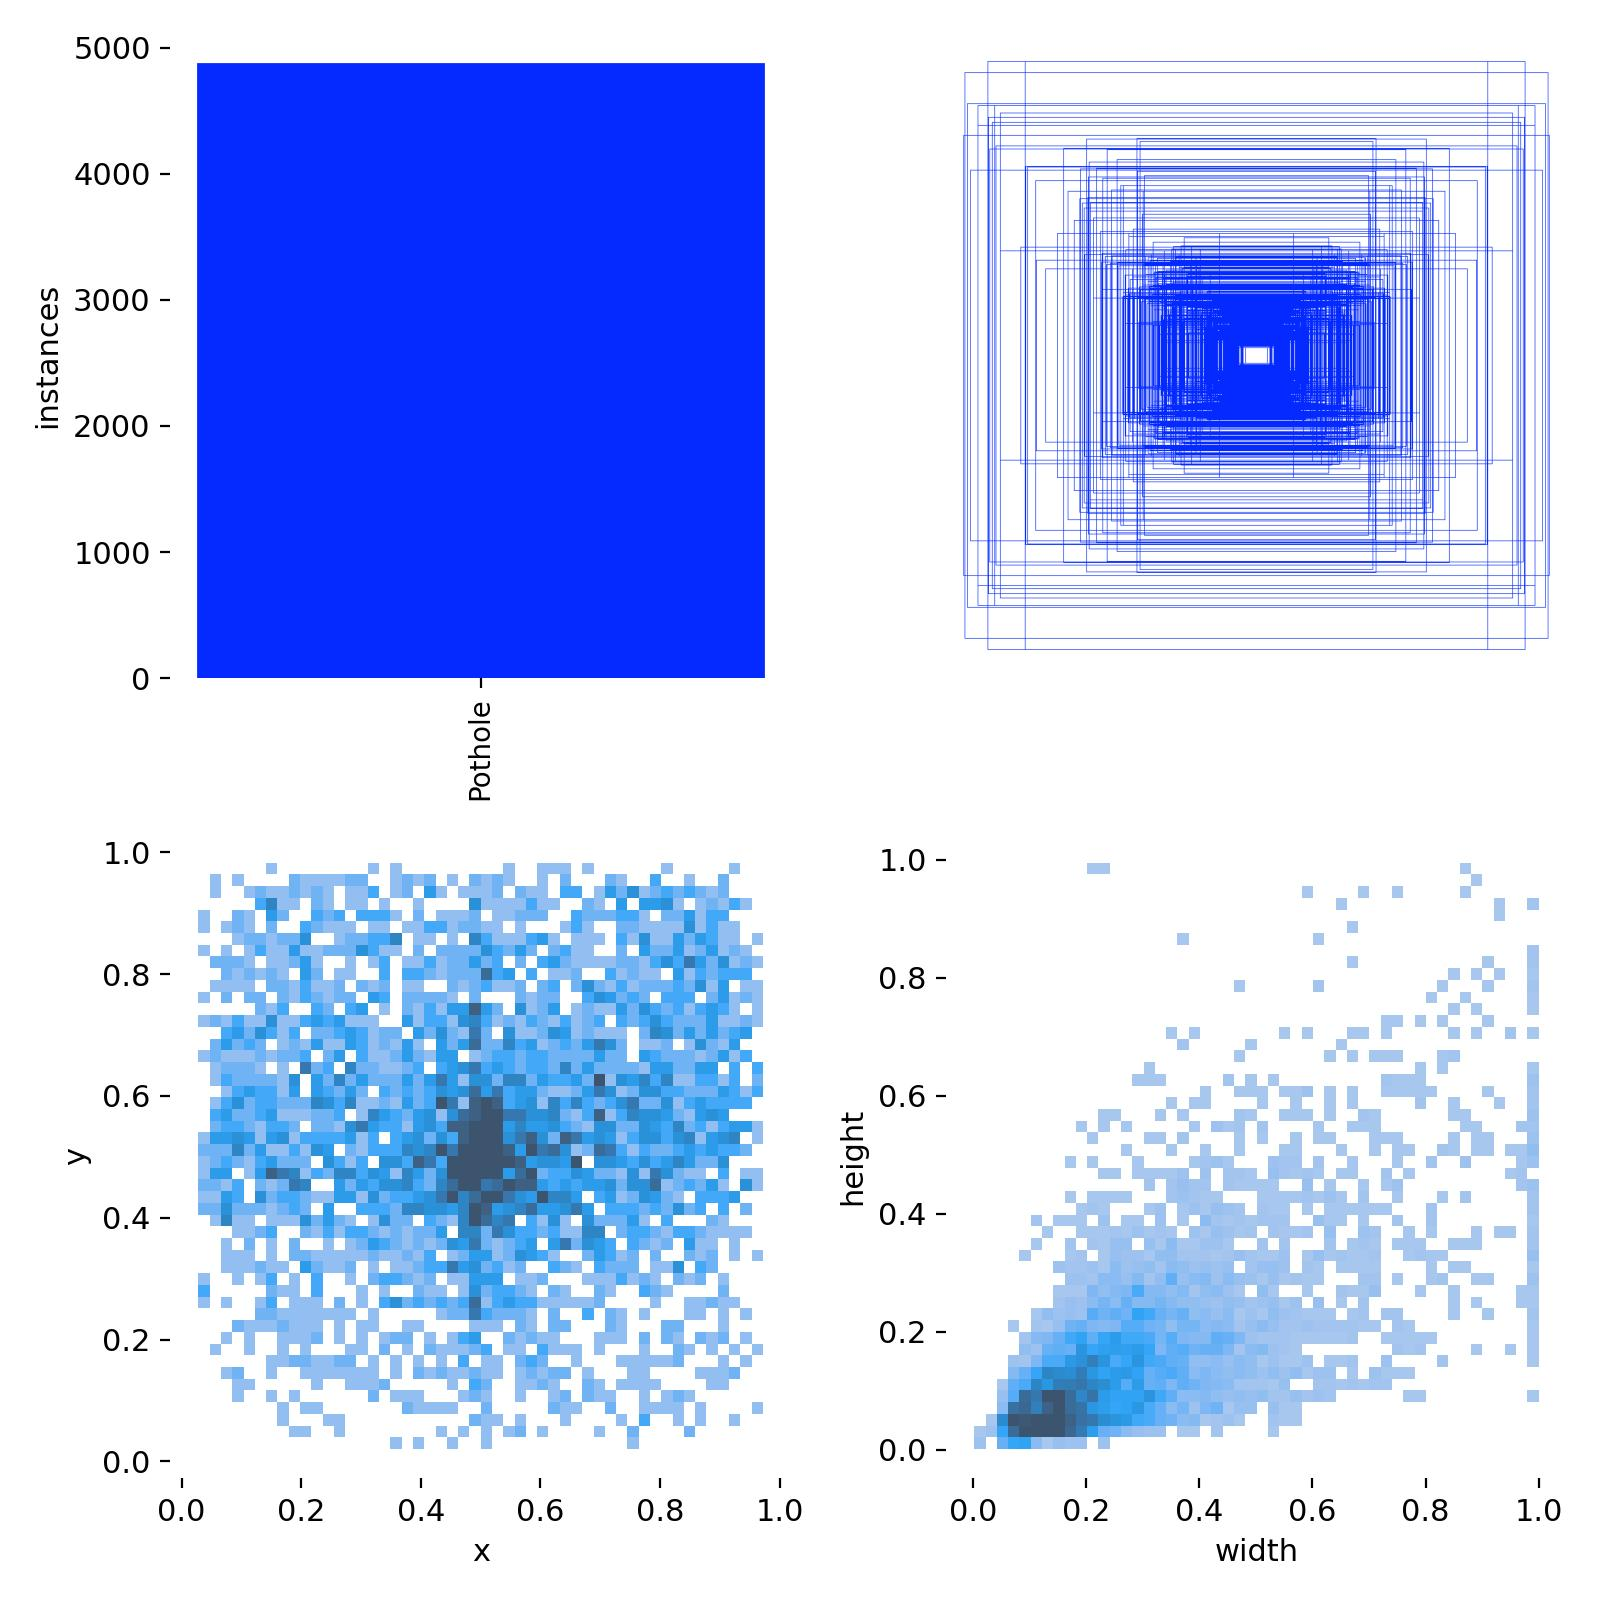

In [10]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/detect/train3/labels.jpg",
    width=1000
))

In [6]:
import os

# List the contents of the training output directory
print(f"Listing contents of {HOME}/runs/detect/train2/")
!ls -R {HOME}/runs/detect/train2/

Listing contents of /content/runs/detect/train2/
/content/runs/detect/train2/:
args.yaml					    labels.jpg
events.out.tfevents.1789920422.72604a614a53.6232.0  train_batch0.jpg
labels_correlogram.jpg				    weights

/content/runs/detect/train2/weights:


In [9]:
import os

# List all 'train' directories under runs/detect/
print("Searching for training result directories...")
!find {HOME}/runs/detect/ -type d -name "train*"

# List the contents of the 'train' directory
print(f"Listing contents of {HOME}/runs/detect/train/")
!ls -R {HOME}/runs/detect/train/

Searching for training result directories...
/content/runs/detect/train3
/content/runs/detect/train2
/content/runs/detect/train
Listing contents of /content/runs/detect/train/
/content/runs/detect/train/:
args.yaml					    labels.jpg
events.out.tfevents.1789919667.72604a614a53.3081.0  train_batch0.jpg
labels_correlogram.jpg				    weights

/content/runs/detect/train/weights:


In [13]:
import supervision as sv
import os

# Ensure dataset_location is defined
# If 'dataset' object is available from previous cells, use its location.
# Otherwise, default to the expected download path based on HOME.
try:
    # Attempt to use dataset.location if dataset object is defined
    dataset_location = dataset.location
except NameError:
    # Fallback to a common Roboflow download location if dataset is not defined
    dataset_location = os.path.join(HOME, "Pothole-1")

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

ds.classes

['Pothole']

In [29]:
from supervision.metrics import MeanAveragePrecision
import supervision as sv

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]

    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map_metric = MeanAveragePrecision()

map_metric.update(
    predictions,
    targets
)

map_result = map_metric.compute()

print(map_result)

AttributeError: 'AAttn' object has no attribute 'qk'

In [28]:
from supervision.metrics import MeanAveragePrecision
from ultralytics import YOLO
import os

# The best.pt model was not found, so loading the initial yolo12s.pt model for demonstration.
# Please verify why best.pt/last.pt were not saved during training.
model = YOLO(f'{HOME}/yolo12s.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

AttributeError: 'AAttn' object has no attribute 'qk'

In [20]:
import os

# Search for 'last.pt' within the entire /content/ directory
!find /content/ -name "last.pt"

In [ ]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

In [ ]:
map.plot()

## Run inference with fine-tuned YOLOv12 model

In [ ]:
import supervision as sv

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

In [ ]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)